# Part 1 — Policy Gradient Training (Colab)

Runs on a **GPU runtime**. Make sure you have selected:


In [ ]:
# ── Step 1: Check GPU ──────────────────────────────────────────────────────
import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices("GPU"))
print("TF version:", tf.__version__)

In [ ]:
# ── Step 2: Upload required files ──────────────────────────────────────────
# Upload ALL of these files:
#   connect4_env.py
#   loader.py                  (from models/loader.py)
#   josh_cnn.h5                (from models/josh_cnn.h5)
#   m1_iter200.keras           (from pg_checkpoints/)
#   m1_pg_final.keras          (from pg_checkpoints/ — becomes M1)

from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

In [ ]:
# ── Step 3: Wire up folders so imports work ────────────────────────────────
import os, shutil

os.makedirs("models", exist_ok=True)
os.makedirs("checkpoints/pg", exist_ok=True)

if os.path.exists("loader.py"):
    shutil.move("loader.py", "models/loader.py")
if os.path.exists("josh_cnn.h5"):
    shutil.move("josh_cnn.h5", "models/josh_cnn.h5")

for ckpt in ["m1_iter200.keras", "m1_pg_final.keras"]:
    if os.path.exists(ckpt):
        shutil.move(ckpt, f"checkpoints/pg/{ckpt}")

with open("models/__init__.py", "w") as f:
    f.write("")

print("models/:", os.listdir("models"))
print("checkpoints/pg/:", os.listdir("checkpoints/pg"))

In [ ]:
# ── Step 3b: Mount Google Drive for crash-safe checkpointing ───────────────
# Checkpoints will be copied to Drive after every save so a session crash
# never wipes your progress. Skip this cell if you prefer not to use Drive.

from google.colab import drive
drive.mount("/content/drive")

DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/Connect4_PG_Checkpoints/"
import os
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)
print(f"Drive checkpoints will save to: {DRIVE_CHECKPOINT_DIR}")
print("Existing Drive checkpoints:", os.listdir(DRIVE_CHECKPOINT_DIR))

In [ ]:
# ── Step 4: Hyperparameters — tune these ───────────────────────────────────
GAMMA             = 0.99
LR                = 1e-4
GAMES_PER_ITER    = 10
BATCH_SIZE        = 64     # keep fixed — TF retraces graph if this changes
RANDOM_INIT_MOVES = 3
ENTROPY_COEF      = 0.01
GRAD_CLIP         = 1.0
ADD_TO_POOL_EVERY = 100
MAX_OWN_SNAPSHOTS = 6
N_ITERATIONS      = 300    # 300 more iterations on top of existing training
EVAL_EVERY        = 50
EVAL_GAMES        = 100
CHECKPOINT_DIR    = "checkpoints/pg/"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [ ]:
# ── Step 5: Imports ────────────────────────────────────────────────────────
import random, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from connect4_env import (
    encode_board, legal_moves, game_over, make_board, step,
    ModelAgent, RandomAgent, StrongRuleAgent, evaluate_agents
)
from models.loader import load_model

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("Imports OK")

In [ ]:
# ── Step 6: Load M1 (pg_final — most trained model) ────────────────────────
M1_CHECKPOINT = "checkpoints/pg/m1_pg_final.keras"

m1_model  = keras.models.load_model(M1_CHECKPOINT, compile=False)
optimizer = keras.optimizers.Adam(learning_rate=LR)
print(f"Loaded M1 from {M1_CHECKPOINT}")
m1_model.summary()

In [ ]:
# ── Step 7: Build opponent pool ─────────────────────────────────────────────
from models.loader import load_model

def _make_m2_agent(model):
    return ModelAgent(model, sample=True, strong=True)

opponent_pool = [
    StrongRuleAgent(),
    RandomAgent(),
    _make_m2_agent(load_model("josh_cnn")),                                                     # original — never removed
    _make_m2_agent(keras.models.load_model("checkpoints/pg/m1_iter200.keras", compile=False)),  # run 1 snapshot
    _make_m2_agent(keras.models.load_model("checkpoints/pg/m1_pg_final.keras", compile=False)), # best model so far
]
own_snapshot_count = 2
print(f"Initial pool size: {len(opponent_pool)}")

In [ ]:
# ── Step 8: Helper functions ────────────────────────────────────────────────

def collect_episode(m1_player_id, m2_agent):
    m1_agent = ModelAgent(m1_model, sample=True, strong=False)
    agent1, agent2 = (m1_agent, m2_agent) if m1_player_id == 1 else (m2_agent, m1_agent)
    board = make_board(); current = 1; m1_trans = []

    for _ in range(RANDOM_INIT_MOVES):
        cols = legal_moves(board)
        if not cols: break
        board, _ = step(board, np.random.choice(cols), current)
        done, _ = game_over(board)
        if done: return [], 0
        current = -current

    while True:
        cols = legal_moves(board)
        if not cols: return m1_trans, 0
        if current == m1_player_id:
            enc = encode_board(board, current)
            lmask = np.zeros(7, dtype=np.float32); lmask[cols] = 1.
            col = m1_agent.select_move(board, current)
            m1_trans.append((enc, col, lmask))
        else:
            col = m2_agent.select_move(board, current)
        board, _ = step(board, col, current)
        done, winner = game_over(board)
        if done:
            outcome = 1 if winner == m1_player_id else (-1 if winner != 0 else 0)
            return m1_trans, outcome
        current = -current


def compute_discounted_returns(transitions, outcome, gamma=GAMMA):
    T = len(transitions)
    return [(enc, col, outcome * (gamma ** (T - 1 - t)), lmask)
            for t, (enc, col, lmask) in enumerate(transitions)]


@tf.function
def train_step(boards, cols, returns):
    with tf.GradientTape() as tape:
        probs        = m1_model(boards, training=True)
        log_probs    = tf.math.log(probs + 1e-8)
        indices      = tf.stack([tf.range(BATCH_SIZE, dtype=tf.int32), cols], axis=1)
        chosen       = tf.gather_nd(log_probs, indices)
        entropy      = -tf.reduce_mean(tf.reduce_sum(probs * log_probs, axis=1))
        loss         = -tf.reduce_mean(chosen * returns) - ENTROPY_COEF * entropy
    grads, _ = tf.clip_by_global_norm(
        tape.gradient(loss, m1_model.trainable_variables), GRAD_CLIP)
    optimizer.apply_gradients(zip(grads, m1_model.trainable_variables))
    return loss


def sample_batch(all_triplets):
    idx    = np.random.choice(len(all_triplets), size=BATCH_SIZE, replace=True)
    boards = np.stack([all_triplets[i][0] for i in idx]).astype(np.float32)
    cols   = np.array([all_triplets[i][1] for i in idx], dtype=np.int32)
    rets   = np.array([all_triplets[i][2] for i in idx], dtype=np.float32)
    if rets.std() > 1e-8:
        rets = (rets - rets.mean()) / (rets.std() + 1e-8)
    return tf.constant(boards), tf.constant(cols), tf.constant(rets)


print("Helpers defined")

In [ ]:
# ── Step 9: Training loop ───────────────────────────────────────────────────
log_loss, log_pg_loss = [], []
log_win_rate_strong, log_win_rate_orig, log_iters_eval = [], [], []

eval_strong  = StrongRuleAgent()
eval_orig_m1 = _make_m2_agent(load_model("josh_cnn"))

own_snapshot_count = 0

print(f"Training for {N_ITERATIONS} iterations...
")

for iteration in range(1, N_ITERATIONS + 1):

    m2_agent    = random.choice(opponent_pool)
    all_triplets = []

    for _ in range(GAMES_PER_ITER):
        m1_pid = random.choice([1, -1])
        trans, outcome = collect_episode(m1_pid, m2_agent)
        if not trans: continue
        all_triplets.extend(compute_discounted_returns(trans, outcome))

    if not all_triplets:
        continue

    boards_t, cols_t, rets_t = sample_batch(all_triplets)
    loss = train_step(boards_t, cols_t, rets_t)
    log_loss.append(float(loss))

    if iteration % EVAL_EVERY == 0:
        m1_eval = ModelAgent(m1_model, sample=False, strong=True)
        res_s   = evaluate_agents(m1_eval, eval_strong,  n_games=EVAL_GAMES)
        res_o   = evaluate_agents(m1_eval, eval_orig_m1, n_games=EVAL_GAMES)
        log_win_rate_strong.append(res_s["win_rate"])
        log_win_rate_orig.append(res_o["win_rate"])
        log_iters_eval.append(iteration)
        print(f"[{iteration:>5}] loss={float(loss):.4f} | "
              f"vs Strong: {res_s['win_rate']:.1%} | "
              f"vs OrigM1: {res_o['win_rate']:.1%}")

    if iteration % ADD_TO_POOL_EVERY == 0:
        snap = keras.models.clone_model(m1_model)
        snap.set_weights(m1_model.get_weights())
        opponent_pool.append(_make_m2_agent(snap))
        own_snapshot_count += 1
        if own_snapshot_count > MAX_OWN_SNAPSHOTS:
            opponent_pool.pop(3)
            own_snapshot_count -= 1
        ckpt = f"{CHECKPOINT_DIR}m1_iter{iteration}.keras"
        m1_model.save(ckpt)
        # Auto-copy to Google Drive so crashes don't wipe progress
        try:
            import shutil
            shutil.copy(ckpt, DRIVE_CHECKPOINT_DIR)
            print(f"  → Snapshot saved + backed up to Drive. Pool size: {len(opponent_pool)}")
        except Exception:
            print(f"  → Snapshot saved (Drive backup skipped). Pool size: {len(opponent_pool)}")

print("
Training complete!")

In [ ]:
# ── Step 10: Save final model ───────────────────────────────────────────────
final_path = CHECKPOINT_DIR + "m1_pg_final.keras"
m1_model.save(final_path)
print(f"Saved to {final_path}")

# Back up final model to Drive
try:
    import shutil
    drive_final = DRIVE_CHECKPOINT_DIR + "m1_pg_final.keras"
    shutil.copy(final_path, drive_final)
    print(f"Final model also backed up to Drive: {drive_final}")
except Exception as e:
    print(f"Drive backup skipped: {e}")

In [ ]:
# ── Step 11: Plot training curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Policy Gradient Training — M1 (josh_cnn)", fontsize=13)

window = 20
axes[0].plot(log_loss, alpha=0.3, label="Loss")
if len(log_loss) >= window:
    roll = np.convolve(log_loss, np.ones(window)/window, mode="valid")
    axes[0].plot(range(window-1, len(log_loss)), roll, label=f"MA{window}")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss"); axes[0].legend()

axes[1].plot(log_iters_eval, log_win_rate_strong, marker="o", label="vs Strong")
axes[1].plot(log_iters_eval, log_win_rate_orig,   marker="o", label="vs Orig M1")
axes[1].axhline(0.5, color="gray", linestyle="--", label="50% baseline")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Win Rate")
axes[1].set_title("Win Rates"); axes[1].legend(); axes[1].set_ylim(0, 1)

plt.tight_layout()
plot_path = CHECKPOINT_DIR + "pg_training_curves.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")

In [ ]:
# ── Step 12: Download trained model ────────────────────────────────────────
from google.colab import files
files.download(CHECKPOINT_DIR + "m1_pg_final.keras")
files.download(CHECKPOINT_DIR + "pg_training_curves.png")

# Part 4 — DQN Training (Local)
**Optimization 2 · Project 3 · Connect-4**

### How to use
1. Set `TEST_MODE = True` for a quick 200 episode verification run
2. If test looks good, set `TEST_MODE = False` and run overnight
3. All files load automatically from your Downloads folder
4. Checkpoints save locally every 500 episodes so you never lose progress

In [ ]:
# ── Step 1: Check GPU ──────────────────────────────────────────────────────
import tensorflow as tf
import torch
print('GPUs available:', tf.config.list_physical_devices('GPU'))
print('TF version:', tf.__version__)
print('PyTorch version:', torch.__version__)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.19.0
PyTorch version: 2.10.0+cu128


In [ ]:
# ── Step 2: Upload all files ───────────────────────────────────────────────
# Upload ALL of these when prompted:
#   connect4_env.py
#   loader.py
#   josh_cnn.h5
#   abhay_cnn.keras
#   connect4_cnn.pt          (Prisca)
#   emily_cnn.pt             (Emily)
#   connect4_transformer.pt
#   m1_pg_final.keras
# NO checkpoint file needed -- starting fresh

from google.colab import files
uploaded = files.upload()
print('Uploaded:', list(uploaded.keys()))

Saving abhay_cnn.keras to abhay_cnn.keras
Saving connect4_cnn.pt to connect4_cnn.pt
Saving connect4_env.py to connect4_env.py
Saving connect4_transformer.pt to connect4_transformer.pt
Saving emily_cnn.pt to emily_cnn.pt
Saving josh_cnn.h5 to josh_cnn.h5
Saving loader.py to loader.py
Saving m1_pg_final.keras to m1_pg_final.keras
Uploaded: ['abhay_cnn.keras', 'connect4_cnn.pt', 'connect4_env.py', 'connect4_transformer.pt', 'emily_cnn.pt', 'josh_cnn.h5', 'loader.py', 'm1_pg_final.keras']


In [ ]:
# ── Step 3: Wire up folders ────────────────────────────────────────────────
import os, shutil

CHECKPOINT_DIR = 'checkpoints/'
BEST_MODEL_DIR = 'best_model/'

os.makedirs('models',        exist_ok=True)
os.makedirs(CHECKPOINT_DIR,  exist_ok=True)
os.makedirs(BEST_MODEL_DIR,  exist_ok=True)
os.makedirs('part1_pg/best_model', exist_ok=True)

for fname, dest in [
    ('loader.py',              'models/loader.py'),
    ('josh_cnn.h5',            'models/josh_cnn.h5'),
    ('abhay_cnn.keras',        'models/abhay_cnn.keras'),
    ('m1_pg_final.keras',      'part1_pg/best_model/m1_pg_final.keras'),
]:
    if os.path.exists(fname):
        shutil.copy(fname, dest)
        print(f'  {fname} -> {dest}')

# move checkpoint into checkpoints folder
for fname in os.listdir('.'):
    if fname.startswith('dqn_ep') and fname.endswith('.keras'):
        shutil.copy(fname, os.path.join(CHECKPOINT_DIR, fname))
        print(f'  {fname} -> {CHECKPOINT_DIR}')

with open('models/__init__.py', 'w') as f:
    f.write('')

print('models/:', os.listdir('models'))

  loader.py -> models/loader.py
  josh_cnn.h5 -> models/josh_cnn.h5
  abhay_cnn.keras -> models/abhay_cnn.keras
  m1_pg_final.keras -> part1_pg/best_model/m1_pg_final.keras
models/: ['loader.py', 'abhay_cnn.keras', 'josh_cnn.h5', '__init__.py']


In [ ]:
# ── Step 4: Mount Google Drive for crash-safe checkpointing ───────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/Connect4_DQN_Checkpoints/'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive checkpoints -> {DRIVE_DIR}')
print('Existing:', os.listdir(DRIVE_DIR))

Mounted at /content/drive
Drive checkpoints -> /content/drive/MyDrive/Connect4_DQN_Checkpoints/
Existing: []


In [ ]:
# ── Step 5: Hyperparameters ────────────────────────────────────────────────
GAMMA               = 0.99
LR                  = 1e-4
BATCH_SIZE          = 64
REPLAY_BUFFER_SIZE  = 50000
TARGET_UPDATE_EVERY = 1000
MIN_BUFFER_SIZE     = 1000
EPSILON_START       = 1.0
EPSILON_END         = 0.05
EPSILON_DECAY_STEPS = 75000
N_EPISODES          = 5000
RANDOM_INIT_MOVES   = 4
TRAIN_EVERY         = 4
ADD_TO_POOL_EVERY   = 200
MAX_OWN_SNAPSHOTS   = 6
EVAL_EVERY          = 100
EVAL_GAMES          = 100
FIXED_POOL_SIZE     = 8
CHECKPOINT_EVERY    = 500
print('Hyperparameters set.')

Hyperparameters set.


In [ ]:
# ── Step 6: Imports ────────────────────────────────────────────────────────
import random, collections
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import torch.nn as nn
import torch.nn.functional as F

from connect4_env import (
    encode_board, legal_moves, game_over, make_board, step,
    ModelAgent, RandomAgent, StrongRuleAgent, evaluate_agents,
    find_winning_move
)
from models.loader import load_agent

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('Imports OK')

Imports OK


In [ ]:
# ── Step 7: PyTorch model definitions ─────────────────────────────────────

class Connect4CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1    = nn.Conv2d(2, 64,  kernel_size=3, padding=1)
        self.conv2    = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3    = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.fc1      = nn.Linear(256 * 6 * 7, 256)
        self.fc2      = nn.Linear(256, 128)
        self.fc_out   = nn.Linear(128, 7)
        self.dropout1 = nn.Dropout(0.4)
        self.dropout2 = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc_out(x)
        x = torch.clamp(x, -10, 10)
        return F.softmax(x, dim=1)


class EmilyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(2,   64,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.fc1   = nn.Linear(512, 1024)
        self.fc2   = nn.Linear(1024, 7)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = x.mean(dim=[2, 3])
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class Connect4Transformer(nn.Module):
    def __init__(self, num_patches=42, patch_size=2, hidden_dim=128,
                 num_layers=6, num_heads=8, mlp_dim=256,
                 dropout_rate=0.3, num_classes=7):
        super().__init__()
        self.patch_embedding = nn.Linear(patch_size, hidden_dim)
        self.row_embedding   = nn.Embedding(6, hidden_dim // 2)
        self.col_embedding   = nn.Embedding(7, hidden_dim // 2)
        self.class_token     = nn.Parameter(torch.randn(1, 1, hidden_dim))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=mlp_dim,
            dropout=dropout_rate, activation='gelu',
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(hidden_dim)
        self.head = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embedding(x)
        ri = torch.arange(6, device=x.device).repeat_interleave(7)
        ci = torch.arange(7, device=x.device).repeat(6)
        pos = torch.cat([self.row_embedding(ri), self.col_embedding(ci)], dim=-1)
        x = x + pos.unsqueeze(0)
        x = torch.cat([self.class_token.expand(B, -1, -1), x], dim=1)
        x = self.transformer(x)
        return self.head(self.norm(x[:, 0]))


class CNNAgent:
    def __init__(self, model, channels_first=True, strong=True):
        self.model          = model.cpu().eval()
        self.channels_first = channels_first
        self.strong         = strong

    def select_move(self, board, player):
        if self.strong:
            col = find_winning_move(board, player)
            if col is not None: return col
            col = find_winning_move(board, -player)
            if col is not None: return col
        legal = legal_moves(board)
        if self.channels_first:
            enc = np.zeros((2, 6, 7), dtype=np.float32)
            enc[0] = (board == player)
            enc[1] = (board == -player)
        else:
            enc = np.zeros((6, 7, 2), dtype=np.float32)
            enc[:, :, 0] = (board == player)
            enc[:, :, 1] = (board == -player)
        inp = torch.tensor(enc).unsqueeze(0).cpu()
        with torch.no_grad():
            out = self.model(inp)[0].numpy()
        mask = np.full(7, -1e9); mask[legal] = 0.0
        return int(np.argmax(out + mask))


class TransformerAgent:
    def __init__(self, model, strong=True):
        self.model  = model.cpu().eval()
        self.strong = strong

    def select_move(self, board, player):
        if self.strong:
            col = find_winning_move(board, player)
            if col is not None: return col
            col = find_winning_move(board, -player)
            if col is not None: return col
        legal = legal_moves(board)
        enc = np.zeros((6, 7, 2), dtype=np.float32)
        enc[:, :, 0] = (board == player)
        enc[:, :, 1] = (board == -player)
        patches = torch.tensor(enc.reshape(1, 42, 2)).cpu()
        with torch.no_grad():
            logits = self.model(patches)[0].numpy()
        mask = np.full(7, -1e9); mask[legal] = 0.0
        return int(np.argmax(logits + mask))


print('Model classes defined.')

Model classes defined.


In [ ]:
# ── Step 8: Load all models ────────────────────────────────────────────────

# PyTorch models
prisca_model = Connect4CNN()
prisca_model.load_state_dict(
    torch.load('connect4_cnn.pt', map_location='cpu', weights_only=True))
prisca_agent = CNNAgent(prisca_model, channels_first=True, strong=True)
print('Prisca CNN loaded.')

emily_model = EmilyCNN()
emily_sd = torch.load('emily_cnn.pt', map_location='cpu', weights_only=False)
if not isinstance(emily_sd, dict):
    emily_sd = emily_sd.state_dict()
emily_model.load_state_dict(emily_sd)
emily_agent = CNNAgent(emily_model, channels_first=True, strong=True)
print('Emily CNN loaded.')

transformer_model = torch.load(
    'connect4_transformer.pt', map_location='cpu', weights_only=False)
transformer_model.eval()
transformer_agent = TransformerAgent(transformer_model, strong=True)
print('Transformer loaded.')

# Keras models
josh_agent  = load_agent('josh_cnn')
abhay_agent = load_agent('abhay_cnn')
pg_model    = keras.models.load_model(
    'part1_pg/best_model/m1_pg_final.keras', compile=False)
pg_agent    = ModelAgent(pg_model, sample=False, strong=True)
print('Josh, Abhay, PG loaded.')

Prisca CNN loaded.
Emily CNN loaded.
Transformer loaded.
Josh, Abhay, PG loaded.


In [ ]:
# ── Step 9: Build DQN ──────────────────────────────────────────────────────

def build_dqn():
    inp = keras.Input(shape=(6, 7, 2))
    x   = layers.Conv2D(64,  3, padding='same', activation='relu')(inp)
    x   = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x   = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(7, activation='tanh', name='q_values')(x)
    return keras.Model(inp, out, name='Connect4DQN')

dqn_online = build_dqn()
dqn_target = build_dqn()
dqn_target.set_weights(dqn_online.get_weights())
optimizer  = keras.optimizers.Adam(learning_rate=LR)
print('DQN built.')
dqn_online.summary()

DQN built.


Model: "Connect4DQN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6, 7, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 6, 7, 64)       │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,376,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_values (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,632,967 (6.23 MB)

 Trainable params: 1,632,967 (6.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Step 10: Replay Buffer ─────────────────────────────────────────────────

class ReplayBuffer:
    def __init__(self, maxlen=REPLAY_BUFFER_SIZE):
        self.buf = collections.deque(maxlen=maxlen)

    def add(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, done))

    def sample(self, n=BATCH_SIZE):
        batch = random.sample(self.buf, n)
        s, a, r, s2, d = zip(*batch)
        return (np.array(s,  dtype=np.float32),
                np.array(a,  dtype=np.int32),
                np.array(r,  dtype=np.float32),
                np.array(s2, dtype=np.float32),
                np.array(d,  dtype=np.float32))

    def __len__(self): return len(self.buf)

replay_buffer = ReplayBuffer()
print('Replay buffer ready.')

Replay buffer ready.


In [ ]:
# ── Step 11: Opponent pool ─────────────────────────────────────────────────

def _keras_agent(model):
    return ModelAgent(model, sample=True, strong=True)

opponent_pool = [
    RandomAgent(),        # 0 - never removed
    StrongRuleAgent(),    # 1 - never removed
    josh_agent,           # 2 - never removed
    abhay_agent,          # 3 - never removed
    prisca_agent,         # 4 - never removed
    emily_agent,          # 5 - never removed
    transformer_agent,    # 6 - never removed
    pg_agent,             # 7 - never removed
]
own_snapshot_count = 0
print(f'Pool size: {len(opponent_pool)}')

Pool size: 8


In [ ]:
# ── Step 12: Helper functions ──────────────────────────────────────────────

total_steps = 0

def get_epsilon():
    frac = min(total_steps / EPSILON_DECAY_STEPS, 1.0)
    return EPSILON_START + frac * (EPSILON_END - EPSILON_START)

def select_move_dqn(board, player, epsilon):
    legal = legal_moves(board)
    if random.random() < epsilon:
        return random.choice(legal)
    enc   = encode_board(board, player)[np.newaxis].astype(np.float32)
    qvals = dqn_online(enc, training=False).numpy()[0]
    mask  = np.full(7, -1e9); mask[legal] = 0.0
    return int(np.argmax(qvals + mask))

@tf.function
def train_step(states, actions, rewards, next_states, dones):
    max_next = tf.reduce_max(dqn_target(next_states, training=False), axis=1)
    targets  = rewards + GAMMA * max_next * (1.0 - dones)
    with tf.GradientTape() as tape:
        qvals    = dqn_online(states, training=True)
        indices  = tf.stack([tf.range(BATCH_SIZE, dtype=tf.int32), actions], axis=1)
        chosen_q = tf.gather_nd(qvals, indices)
        loss     = tf.reduce_mean(tf.square(targets - chosen_q))
    grads, _ = tf.clip_by_global_norm(
        tape.gradient(loss, dqn_online.trainable_variables), 1.0)
    optimizer.apply_gradients(zip(grads, dqn_online.trainable_variables))
    return loss

def sync_target():
    dqn_target.set_weights(dqn_online.get_weights())

def play_episode(m2_agent, epsilon):
    """next_state captured AFTER opponent responds -- correct for 2-player DQN"""
    global total_steps
    dqn_player = random.choice([1, -1])
    board      = make_board()
    current    = 1

    # random warm-start, not recorded
    for _ in range(RANDOM_INIT_MOVES):
        cols = legal_moves(board)
        if not cols: break
        board, _ = step(board, np.random.choice(cols), current)
        done, winner = game_over(board)
        if done: return winner
        current = -current

    # advance to DQN's turn if needed
    if current != dqn_player:
        cols = legal_moves(board)
        if not cols: return 0
        col = m2_agent.select_move(board, current)
        board, _ = step(board, col, current)
        done, winner = game_over(board)
        if done: return winner
        current = dqn_player

    while True:
        cols = legal_moves(board)
        if not cols: return 0

        state = encode_board(board, dqn_player).astype(np.float32)
        col   = select_move_dqn(board, dqn_player, epsilon)
        total_steps += 1
        board, _ = step(board, col, dqn_player)
        done, winner = game_over(board)

        if done:
            reward     = 1.0 if winner == dqn_player else (0.1 if winner == 0 else -1.0)
            next_state = encode_board(board, dqn_player).astype(np.float32)
            replay_buffer.add(state, col, reward, next_state, True)
            return winner

        # opponent responds
        opp_cols = legal_moves(board)
        if not opp_cols:
            next_state = encode_board(board, dqn_player).astype(np.float32)
            replay_buffer.add(state, col, 0.1, next_state, True)
            return 0

        opp_col = m2_agent.select_move(board, -dqn_player)
        board, _ = step(board, opp_col, -dqn_player)
        done, winner = game_over(board)

        # store AFTER opponent replies
        reward     = -1.0 if (done and winner == -dqn_player) else (0.1 if (done and winner == 0) else 0.0)
        next_state = encode_board(board, dqn_player).astype(np.float32)
        replay_buffer.add(state, col, reward, next_state, float(done))

        if done: return winner

print('Helpers defined.')

Helpers defined.


In [ ]:
# ── Step 13: Start fresh ───────────────────────────────────────────────────
START_EPISODE = 1
total_steps   = 0
print('Starting fresh from episode 1')

# warm up replay buffer so training starts immediately
print(f'Warming up replay buffer to {MIN_BUFFER_SIZE} experiences...')
warmup_agent = StrongRuleAgent()
while len(replay_buffer) < MIN_BUFFER_SIZE:
    play_episode(warmup_agent, epsilon=0.5)
print(f'Buffer ready: {len(replay_buffer)} experiences')

Starting fresh from episode 1
Warming up replay buffer to 1000 experiences...
Buffer ready: 1001 experiences


In [ ]:
# ── Step 14: Training loop ─────────────────────────────────────────────────
log = {k: [] for k in [
    'loss', 'vs_strong', 'vs_random', 'vs_pg',
    'vs_josh', 'vs_abhay', 'vs_prisca', 'vs_emily', 'vs_transformer'
]}
log_iters, log_epsilon = [], []

eval_agents = {
    'vs_strong':      StrongRuleAgent(),
    'vs_random':      RandomAgent(),
    'vs_pg':          ModelAgent(pg_model, sample=False, strong=True),
    'vs_josh':        josh_agent,
    'vs_abhay':       abhay_agent,
    'vs_prisca':      CNNAgent(prisca_model, channels_first=True, strong=True),
    'vs_emily':       CNNAgent(emily_model,  channels_first=True, strong=True),
    'vs_transformer': TransformerAgent(transformer_model, strong=True),
}

loss_accum = []
best_wr    = 0.0

print(f'Training DQN from episode {START_EPISODE} to {N_EPISODES}\n')

for episode in range(START_EPISODE, N_EPISODES + 1):

    epsilon  = get_epsilon()
    m2_agent = random.choice(opponent_pool)
    play_episode(m2_agent, epsilon)

    if len(replay_buffer) >= MIN_BUFFER_SIZE and total_steps % TRAIN_EVERY == 0:
        s, a, r, s2, d = replay_buffer.sample()
        loss = train_step(
            tf.constant(s), tf.constant(a), tf.constant(r),
            tf.constant(s2), tf.constant(d))
        loss_accum.append(float(loss))

    if total_steps > 0 and total_steps % TARGET_UPDATE_EVERY == 0:
        sync_target()

    if episode % EVAL_EVERY == 0:
        dqn_eval = ModelAgent(dqn_online, sample=False, strong=True)
        avg_loss = np.mean(loss_accum) if loss_accum else 0.0
        log['loss'].append(avg_loss)
        loss_accum.clear()

        for key, opp in eval_agents.items():
            wr = evaluate_agents(dqn_eval, opp, n_games=EVAL_GAMES)['win_rate']
            log[key].append(wr)

        log_iters.append(episode)
        log_epsilon.append(epsilon)

        print(f'[ep {episode:>5}] eps={epsilon:.3f} loss={avg_loss:.4f} | '
              f'Strong:{log["vs_strong"][-1]:.0%} '
              f'PG:{log["vs_pg"][-1]:.0%} '
              f'Josh:{log["vs_josh"][-1]:.0%} '
              f'Random:{log["vs_random"][-1]:.0%} '
              f'buf={len(replay_buffer)}')

        if log['vs_strong'][-1] > best_wr:
            best_wr = log['vs_strong'][-1]
            dqn_online.save(BEST_MODEL_DIR + 'dqn_best.keras')
            try:
                shutil.copy(BEST_MODEL_DIR + 'dqn_best.keras',
                            DRIVE_DIR + 'dqn_best.keras')
            except Exception: pass
            print(f'  New best: {best_wr:.1%} vs Strong')

    if episode % ADD_TO_POOL_EVERY == 0:
        snap = build_dqn()
        snap.set_weights(dqn_online.get_weights())
        opponent_pool.append(_keras_agent(snap))
        own_snapshot_count += 1
        if own_snapshot_count > MAX_OWN_SNAPSHOTS:
            opponent_pool.pop(FIXED_POOL_SIZE)
            own_snapshot_count -= 1

    if episode % CHECKPOINT_EVERY == 0:
        ckpt = f'{CHECKPOINT_DIR}dqn_ep{episode}.keras'
        dqn_online.save(ckpt)
        try:
            shutil.copy(ckpt, DRIVE_DIR + f'dqn_ep{episode}.keras')
            print(f'  Checkpoint + Drive backup: dqn_ep{episode}.keras')
        except Exception:
            print(f'  Checkpoint saved: dqn_ep{episode}.keras')

print(f'\nTraining complete! Best vs Strong: {best_wr:.1%}')

Training DQN from episode 1 to 5000

[ep   100] eps=0.981 loss=0.1606 | Strong:22% PG:0% Josh:0% Random:94% buf=1486
  New best: 22.0% vs Strong
[ep   200] eps=0.975 loss=0.1716 | Strong:30% PG:0% Josh:0% Random:97% buf=1988
  New best: 30.0% vs Strong
[ep   300] eps=0.968 loss=0.1623 | Strong:35% PG:0% Josh:50% Random:96% buf=2553
  New best: 35.0% vs Strong
[ep   400] eps=0.961 loss=0.1777 | Strong:41% PG:0% Josh:0% Random:97% buf=3087
  New best: 41.0% vs Strong
[ep   500] eps=0.954 loss=0.1630 | Strong:40% PG:50% Josh:50% Random:96% buf=3649
  Checkpoint + Drive backup: dqn_ep500.keras
[ep   600] eps=0.946 loss=0.1503 | Strong:45% PG:50% Josh:0% Random:97% buf=4234
  New best: 45.0% vs Strong
[ep   700] eps=0.939 loss=0.1437 | Strong:16% PG:0% Josh:0% Random:95% buf=4785
[ep   800] eps=0.932 loss=0.1238 | Strong:46% PG:0% Josh:0% Random:99% buf=5343
  New best: 46.0% vs Strong
[ep   900] eps=0.925 loss=0.1300 | Strong:48% PG:0% Josh:50% Random:98% buf=5921
  New best: 48.0% vs Stro

In [ ]:
# ── Step 15: Save and download ─────────────────────────────────────────────
dqn_online.save(BEST_MODEL_DIR + 'dqn_final.keras')
print('Final model saved.')

from google.colab import files
files.download(BEST_MODEL_DIR + 'dqn_final.keras')
files.download(BEST_MODEL_DIR + 'dqn_best.keras')

Final model saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

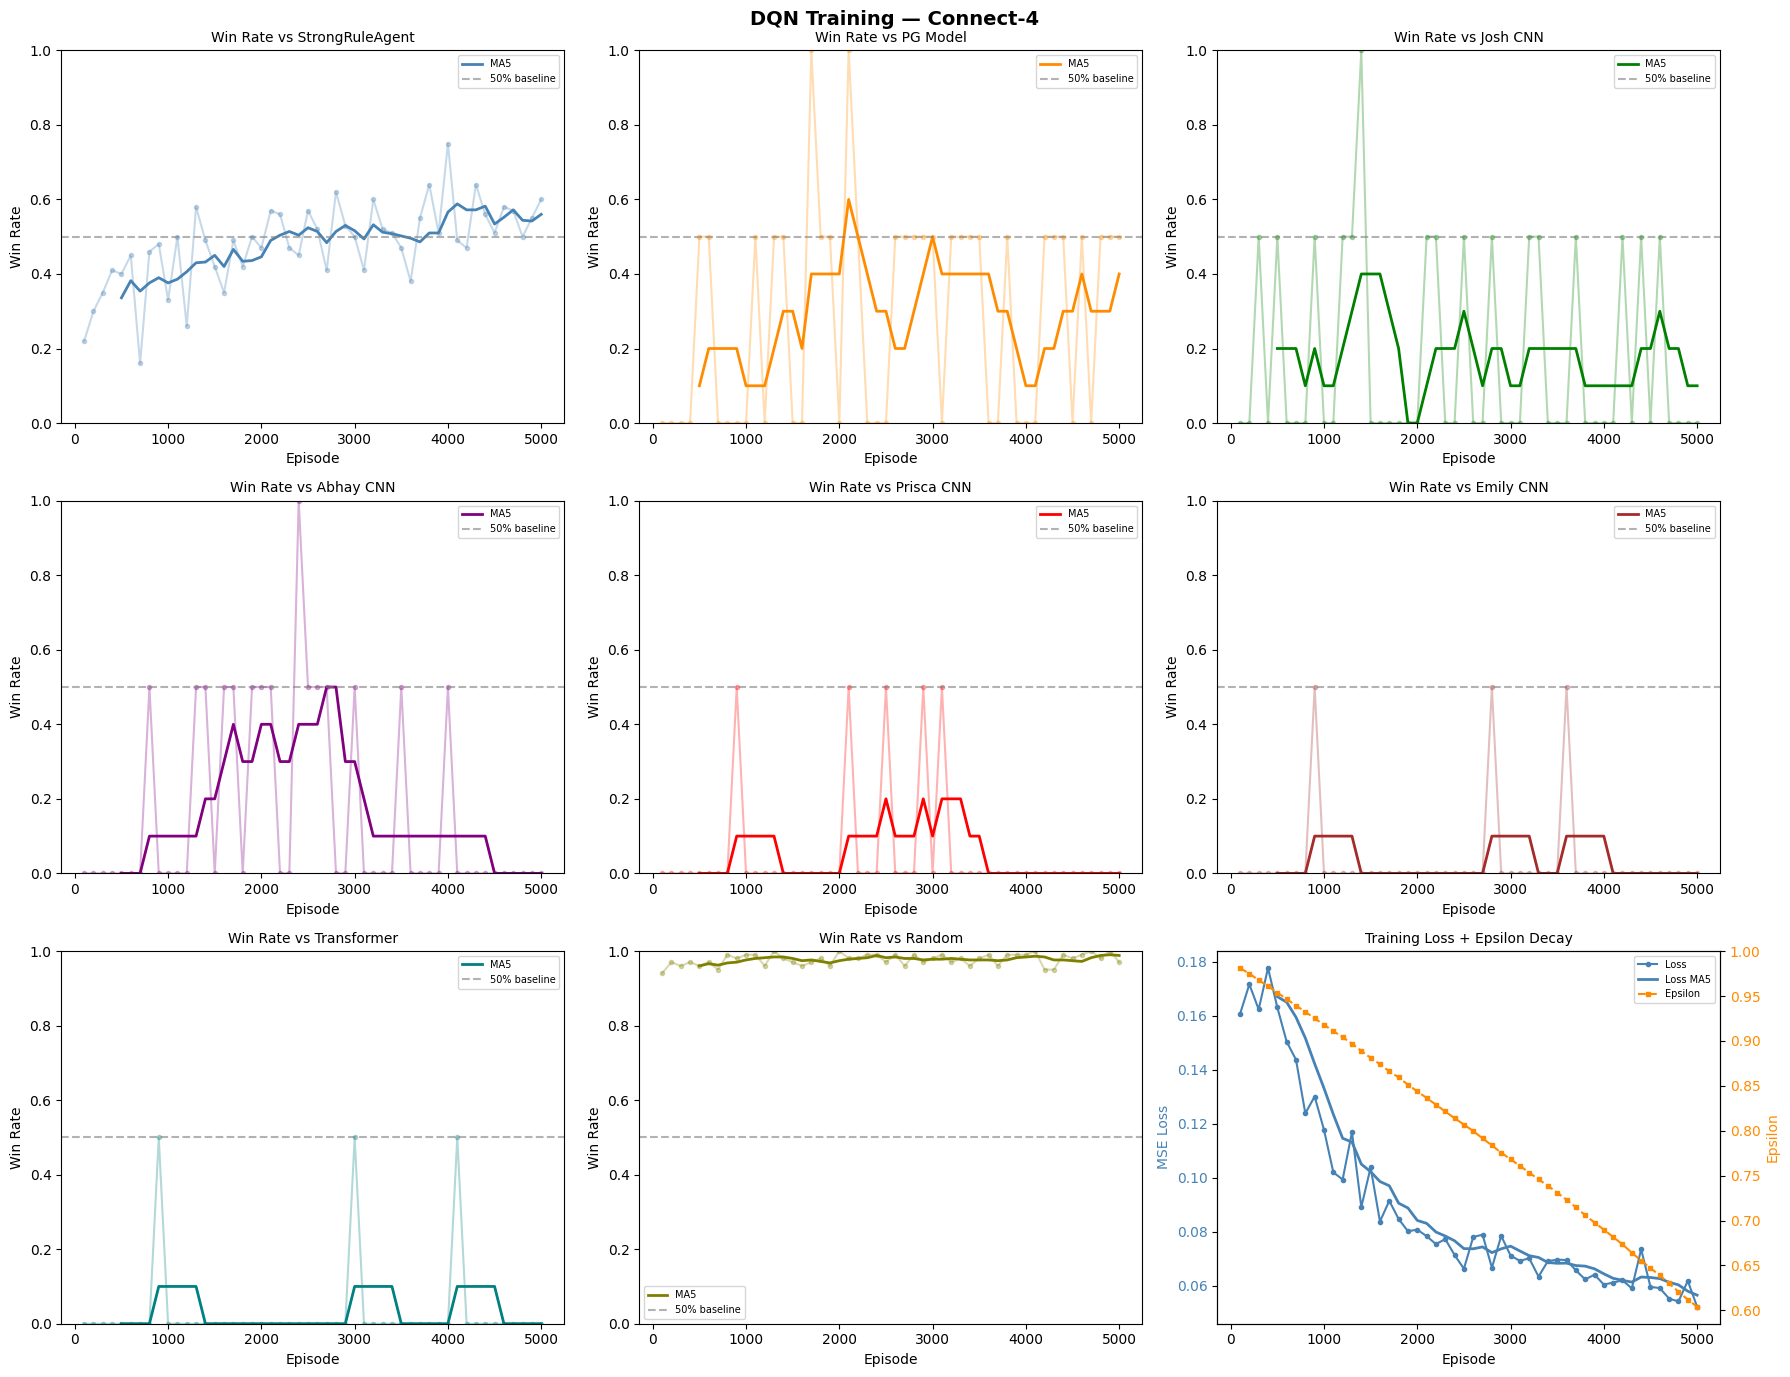

Plot saved: best_model/dqn_training_curves.png


In [ ]:
# ── Plotting ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('DQN Training — Connect-4', fontsize=14, fontweight='bold')

# rolling average window
window = 5

def plot_with_rolling(ax, x, y, label, color, show_baseline=True):
    ax.plot(x, y, marker='o', markersize=3, alpha=0.3, color=color)
    if len(y) >= window:
        roll = np.convolve(y, np.ones(window)/window, mode='valid')
        roll_x = x[window-1:]
        ax.plot(roll_x, roll, color=color, linewidth=2, label=f'MA{window}')
    if show_baseline:
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='50% baseline')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Episode')
    ax.legend(fontsize=7)

log_iters_arr = np.array(log_iters)

# ── Win rates vs each opponent ──
plot_configs = [
    ('vs_strong',      'Win Rate vs StrongRuleAgent', 'steelblue'),
    ('vs_pg',          'Win Rate vs PG Model',         'darkorange'),
    ('vs_josh',        'Win Rate vs Josh CNN',          'green'),
    ('vs_abhay',       'Win Rate vs Abhay CNN',         'purple'),
    ('vs_prisca',      'Win Rate vs Prisca CNN',        'red'),
    ('vs_emily',       'Win Rate vs Emily CNN',         'brown'),
    ('vs_transformer', 'Win Rate vs Transformer',       'teal'),
    ('vs_random',      'Win Rate vs Random',            'olive'),
]

for idx, (key, title, color) in enumerate(plot_configs):
    r, c = divmod(idx, 3)
    ax = axes[r][c]
    plot_with_rolling(ax, log_iters_arr, np.array(log[key]), key, color)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Win Rate')

# ── Bottom right: loss + epsilon on twin axis ──
ax_loss = axes[2][2]
ax_eps  = ax_loss.twinx()

ax_loss.plot(log_iters_arr, log['loss'],    color='steelblue', marker='o',
             markersize=3, label='Loss')
ax_eps.plot(log_iters_arr,  log_epsilon,    color='darkorange', marker='s',
            markersize=3, linestyle='--', label='Epsilon')

if len(log['loss']) >= window:
    roll_loss = np.convolve(log['loss'], np.ones(window)/window, mode='valid')
    ax_loss.plot(log_iters_arr[window-1:], roll_loss,
                 color='steelblue', linewidth=2, label=f'Loss MA{window}')

ax_loss.set_title('Training Loss + Epsilon Decay', fontsize=10)
ax_loss.set_xlabel('Episode')
ax_loss.set_ylabel('MSE Loss', color='steelblue')
ax_eps.set_ylabel('Epsilon',   color='darkorange')
ax_loss.tick_params(axis='y', labelcolor='steelblue')
ax_eps.tick_params(axis='y',  labelcolor='darkorange')

lines1, labels1 = ax_loss.get_legend_handles_labels()
lines2, labels2 = ax_eps.get_legend_handles_labels()
ax_loss.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

plt.tight_layout()
plot_path = BEST_MODEL_DIR + 'dqn_training_curves.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot saved: {plot_path}')

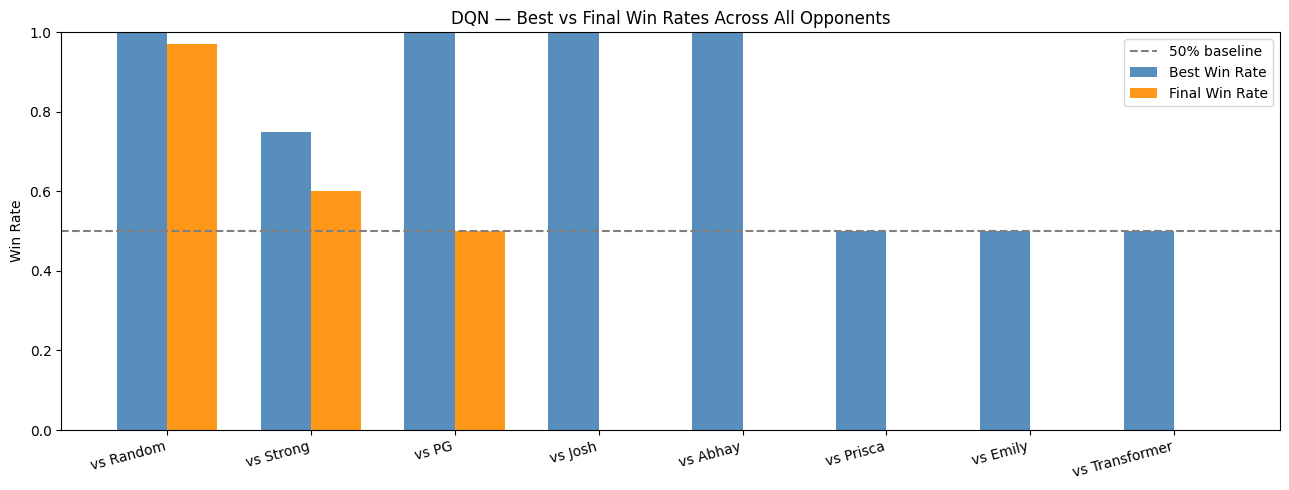

Summary bar chart saved: best_model/dqn_summary_bar.png


In [ ]:
# ── Summary bar chart ──────────────────────────────────────────────────────
opponents  = ['vs Random', 'vs Strong', 'vs PG', 'vs Josh',
              'vs Abhay', 'vs Prisca', 'vs Emily', 'vs Transformer']
best_wrs   = [max(log['vs_random']),      max(log['vs_strong']),
              max(log['vs_pg']),           max(log['vs_josh']),
              max(log['vs_abhay']),        max(log['vs_prisca']),
              max(log['vs_emily']),        max(log['vs_transformer'])]
final_wrs  = [log['vs_random'][-1],       log['vs_strong'][-1],
              log['vs_pg'][-1],            log['vs_josh'][-1],
              log['vs_abhay'][-1],         log['vs_prisca'][-1],
              log['vs_emily'][-1],         log['vs_transformer'][-1]]

x = np.arange(len(opponents))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, best_wrs,  w, label='Best Win Rate',  color='steelblue', alpha=0.9)
ax.bar(x + w/2, final_wrs, w, label='Final Win Rate', color='darkorange', alpha=0.9)
ax.axhline(0.5, color='gray', linestyle='--', label='50% baseline')
ax.set_xticks(x)
ax.set_xticklabels(opponents, rotation=15, ha='right')
ax.set_ylabel('Win Rate')
ax.set_ylim(0, 1)
ax.set_title('DQN — Best vs Final Win Rates Across All Opponents')
ax.legend()
plt.tight_layout()
summary_path = BEST_MODEL_DIR + 'dqn_summary_bar.png'
plt.savefig(summary_path, dpi=150)
plt.show()
print(f'Summary bar chart saved: {summary_path}')

In [ ]:
# ── Download plots ─────────────────────────────────────────────────────────
from google.colab import files
files.download(BEST_MODEL_DIR + 'dqn_training_curves.png')
files.download(BEST_MODEL_DIR + 'dqn_summary_bar.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── Continue training from best checkpoint with faster epsilon decay ────────

# ── Hyperparameter overrides for continuation run ──────────────────────────
EPSILON_START       = 0.60   # start where epsilon roughly left off
EPSILON_END         = 0.05
EPSILON_DECAY_STEPS = 15000  # much faster -- hits 0.05 by ~episode 6500
N_EPISODES_CONT     = 3000   # run 3000 more episodes
EVAL_EVERY          = 100
CHECKPOINT_EVERY    = 500

# ── Load best checkpoint ───────────────────────────────────────────────────
best_ckpt = BEST_MODEL_DIR + 'dqn_best.keras'
dqn_online.load_weights(best_ckpt)
dqn_target.set_weights(dqn_online.get_weights())

# reset total_steps so epsilon starts at 0.60 and decays correctly
total_steps = 0
print(f'Loaded best checkpoint from {best_ckpt}')
print(f'Starting epsilon: {get_epsilon():.3f}')

# ── Warm up buffer ─────────────────────────────────────────────────────────
if len(replay_buffer) < MIN_BUFFER_SIZE:
    print('Warming up replay buffer...')
    while len(replay_buffer) < MIN_BUFFER_SIZE:
        play_episode(StrongRuleAgent(), epsilon=0.3)
    print(f'Buffer ready: {len(replay_buffer)} experiences')

# ── Continuation training loop ─────────────────────────────────────────────
log_cont = {k: [] for k in [
    'loss', 'vs_strong', 'vs_random', 'vs_pg',
    'vs_josh', 'vs_abhay', 'vs_prisca', 'vs_emily', 'vs_transformer'
]}
log_cont_iters, log_cont_epsilon = [], []
loss_accum = []
best_wr_cont = 0.0

START_CONT = 5001
END_CONT   = START_CONT + N_EPISODES_CONT

print(f'\nContinuation run: episodes {START_CONT} to {END_CONT}')
print(f'Epsilon will decay from {EPSILON_START} to {EPSILON_END} over {EPSILON_DECAY_STEPS} steps\n')

for episode in range(START_CONT, END_CONT + 1):

    epsilon  = get_epsilon()
    m2_agent = random.choice(opponent_pool)
    play_episode(m2_agent, epsilon)

    if len(replay_buffer) >= MIN_BUFFER_SIZE and total_steps % TRAIN_EVERY == 0:
        s, a, r, s2, d = replay_buffer.sample()
        loss = train_step(
            tf.constant(s), tf.constant(a), tf.constant(r),
            tf.constant(s2), tf.constant(d))
        loss_accum.append(float(loss))

    if total_steps > 0 and total_steps % TARGET_UPDATE_EVERY == 0:
        sync_target()

    if episode % EVAL_EVERY == 0:
        dqn_eval = ModelAgent(dqn_online, sample=False, strong=True)
        avg_loss = np.mean(loss_accum) if loss_accum else 0.0
        log_cont['loss'].append(avg_loss)
        loss_accum.clear()

        for key, opp in eval_agents.items():
            wr = evaluate_agents(dqn_eval, opp, n_games=EVAL_GAMES)['win_rate']
            log_cont[key].append(wr)

        log_cont_iters.append(episode)
        log_cont_epsilon.append(epsilon)

        print(f'[ep {episode:>5}] eps={epsilon:.3f} loss={avg_loss:.4f} | '
              f'Strong:{log_cont["vs_strong"][-1]:.0%} '
              f'PG:{log_cont["vs_pg"][-1]:.0%} '
              f'Josh:{log_cont["vs_josh"][-1]:.0%} '
              f'Random:{log_cont["vs_random"][-1]:.0%} '
              f'buf={len(replay_buffer)}')

        if log_cont['vs_strong'][-1] > best_wr_cont:
            best_wr_cont = log_cont['vs_strong'][-1]
            dqn_online.save(BEST_MODEL_DIR + 'dqn_best_cont.keras')
            try:
                shutil.copy(BEST_MODEL_DIR + 'dqn_best_cont.keras',
                            DRIVE_DIR + 'dqn_best_cont.keras')
            except Exception: pass
            print(f'  New best: {best_wr_cont:.1%} vs Strong')

    if episode % ADD_TO_POOL_EVERY == 0:
        snap = build_dqn()
        snap.set_weights(dqn_online.get_weights())
        opponent_pool.append(_keras_agent(snap))
        own_snapshot_count += 1
        if own_snapshot_count > MAX_OWN_SNAPSHOTS:
            opponent_pool.pop(FIXED_POOL_SIZE)
            own_snapshot_count -= 1

    if episode % CHECKPOINT_EVERY == 0:
        ckpt = f'{CHECKPOINT_DIR}dqn_ep{episode}.keras'
        dqn_online.save(ckpt)
        try:
            shutil.copy(ckpt, DRIVE_DIR + f'dqn_ep{episode}.keras')
            print(f'  Checkpoint + Drive backup: dqn_ep{episode}.keras')
        except Exception:
            print(f'  Checkpoint saved: dqn_ep{episode}.keras')

print(f'\nContinuation run complete! Best vs Strong: {best_wr_cont:.1%}')

Loaded best checkpoint from best_model/dqn_best.keras
Starting epsilon: 0.600

Continuation run: episodes 5001 to 8001
Epsilon will decay from 0.6 to 0.05 over 15000 steps

[ep  5100] eps=0.578 loss=0.0671 | Strong:54% PG:50% Josh:0% Random:98% buf=31876
  New best: 54.0% vs Strong
[ep  5200] eps=0.553 loss=0.0587 | Strong:42% PG:0% Josh:0% Random:98% buf=32579
[ep  5300] eps=0.528 loss=0.0593 | Strong:59% PG:0% Josh:0% Random:96% buf=33239
  New best: 59.0% vs Strong
[ep  5400] eps=0.503 loss=0.0543 | Strong:57% PG:0% Josh:0% Random:99% buf=33917
[ep  5500] eps=0.479 loss=0.0558 | Strong:47% PG:0% Josh:0% Random:100% buf=34586
  Checkpoint + Drive backup: dqn_ep5500.keras
[ep  5600] eps=0.455 loss=0.0597 | Strong:75% PG:100% Josh:50% Random:98% buf=35242
  New best: 75.0% vs Strong
[ep  5700] eps=0.427 loss=0.0602 | Strong:60% PG:50% Josh:0% Random:100% buf=35988
[ep  5800] eps=0.401 loss=0.0576 | Strong:68% PG:50% Josh:0% Random:99% buf=36700
[ep  5900] eps=0.374 loss=0.0535 | Strong

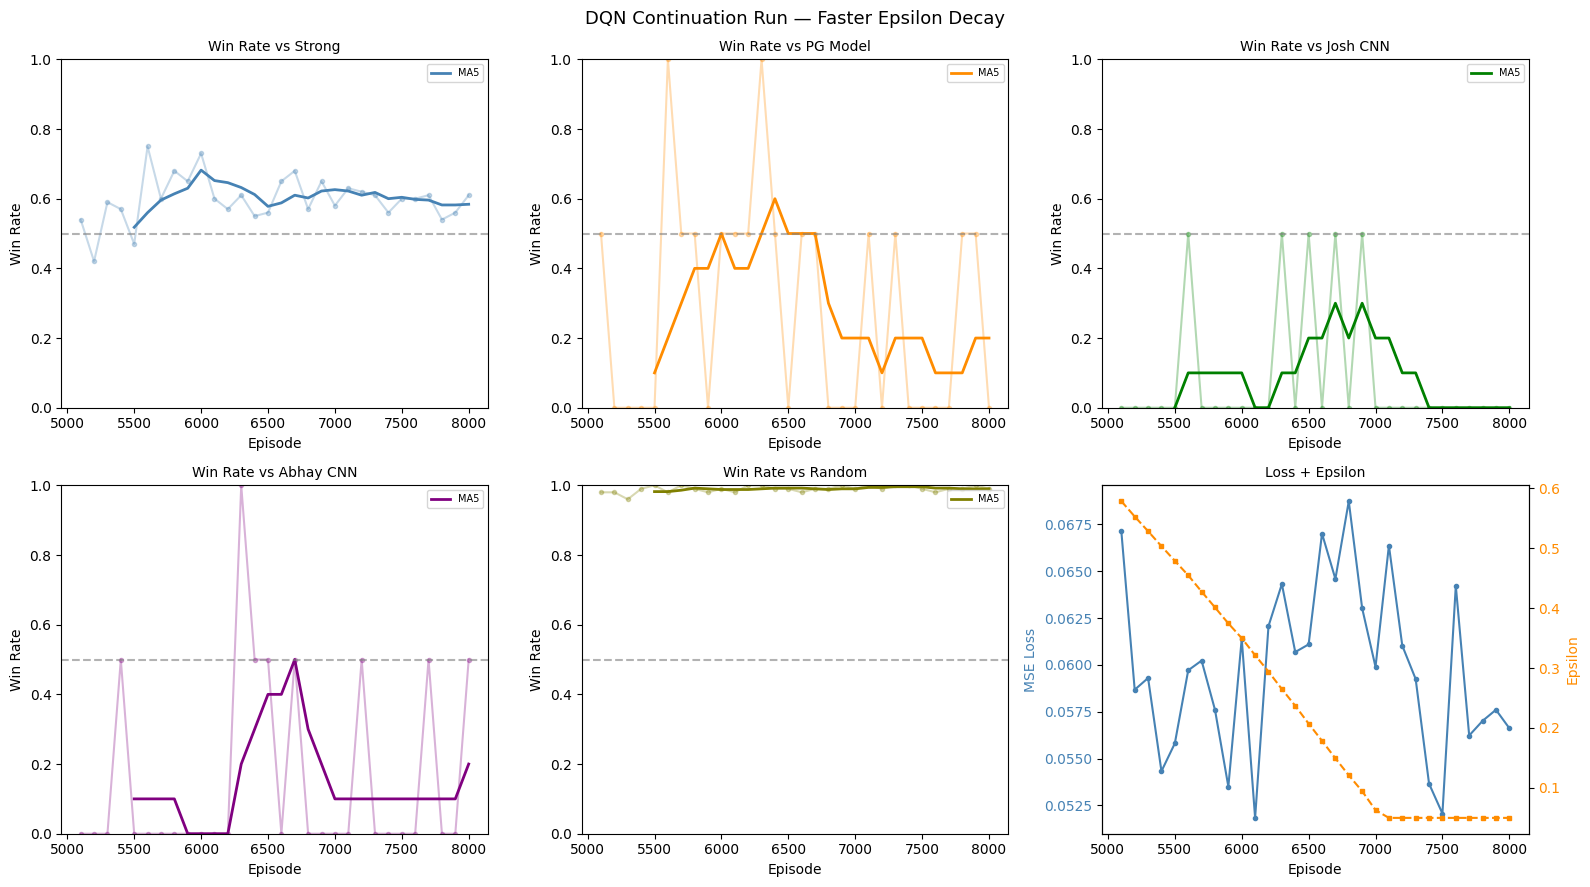

Plot saved: best_model/dqn_continuation_curves.png


In [ ]:
# ── Plot continuation run ──────────────────────────────────────────────────
log_cont_iters_arr = np.array(log_cont_iters)
window = 5

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('DQN Continuation Run — Faster Epsilon Decay', fontsize=13)

cont_plot_configs = [
    ('vs_strong',      'Win Rate vs Strong',      'steelblue'),
    ('vs_pg',          'Win Rate vs PG Model',    'darkorange'),
    ('vs_josh',        'Win Rate vs Josh CNN',    'green'),
    ('vs_abhay',       'Win Rate vs Abhay CNN',   'purple'),
    ('vs_random',      'Win Rate vs Random',      'olive'),
]

for idx, (key, title, color) in enumerate(cont_plot_configs):
    r, c = divmod(idx, 3)
    ax = axes[r][c]
    ax.plot(log_cont_iters_arr, log_cont[key],
            marker='o', markersize=3, alpha=0.3, color=color)
    if len(log_cont[key]) >= window:
        roll = np.convolve(log_cont[key], np.ones(window)/window, mode='valid')
        ax.plot(log_cont_iters_arr[window-1:], roll,
                color=color, linewidth=2, label=f'MA{window}')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Win Rate')
    ax.legend(fontsize=7)

# loss + epsilon on twin axis
ax_loss = axes[1][2]
ax_eps  = ax_loss.twinx()
ax_loss.plot(log_cont_iters_arr, log_cont['loss'],
             color='steelblue', marker='o', markersize=3, label='Loss')
ax_eps.plot(log_cont_iters_arr, log_cont_epsilon,
            color='darkorange', marker='s', markersize=3,
            linestyle='--', label='Epsilon')
ax_loss.set_title('Loss + Epsilon', fontsize=10)
ax_loss.set_xlabel('Episode')
ax_loss.set_ylabel('MSE Loss',  color='steelblue')
ax_eps.set_ylabel('Epsilon',    color='darkorange')
ax_loss.tick_params(axis='y', labelcolor='steelblue')
ax_eps.tick_params(axis='y',  labelcolor='darkorange')

plt.tight_layout()
cont_plot_path = BEST_MODEL_DIR + 'dqn_continuation_curves.png'
plt.savefig(cont_plot_path, dpi=150)
plt.show()
print(f'Plot saved: {cont_plot_path}')

In [ ]:
# ── Download ───────────────────────────────────────────────────────────────
from google.colab import files
files.download(BEST_MODEL_DIR + 'dqn_best_cont.keras')
files.download(BEST_MODEL_DIR + 'dqn_continuation_curves.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part 5 — Model Comparison & Strategies

In this section, we evaluate the performance of our trained reinforcement learning agents:
- Policy Gradient (PG)
- Deep Q-Network (DQN)

We compare them against:
- A random baseline agent
- A strong rule-based agent
- A pretrained CNN (Josh's model)

We measure win rate, draw rate, and loss rate across multiple games to understand
relative performance and generalization.

## Setup: Load Models and Agents

We load all trained models and wrap them in a common `ModelAgent` interface.

Agents used:
- PG agent (policy-based RL)
- DQN agent (value-based RL)
- StrongRuleAgent (heuristic baseline)
- RandomAgent (sanity check baseline)
- Josh's CNN agent (supervised learning baseline)

In [ ]:
# ── Setup & Load Models ──────────────────────────────────────────────────────
import os, shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Upload your files first
from google.colab import files
uploaded = files.upload()
# Upload: connect4_env.py, loader.py, josh_cnn.h5,
#         m1_pg_final.keras, dqn_best_cont.keras

# Copy required files into models/ directory for import compatibility
os.makedirs("models", exist_ok=True)
for fname, dest in [
    ("loader.py",   "models/loader.py"),
    ("josh_cnn.h5", "models/josh_cnn.h5"),
]:
    if os.path.exists(fname):
        shutil.copy(fname, dest)
with open("models/__init__.py", "w") as f:
    f.write("")

from connect4_env import (
    encode_board, legal_moves, game_over, make_board, step,
    ModelAgent, RandomAgent, StrongRuleAgent, evaluate_agents,
    find_winning_move
)
from models.loader import load_model

# Load your two trained models
pg_model  = keras.models.load_model("m1_pg_final.keras",  compile=False)
dqn_model = keras.models.load_model("dqn_best_cont.keras", compile=False)

# Wrap models as agents with greedy (deterministic) play + rule-based safety
pg_agent  = ModelAgent(pg_model,  sample=False, strong=True)
dqn_agent = ModelAgent(dqn_model, sample=False, strong=True)

strong_agent = StrongRuleAgent()
random_agent = RandomAgent()
josh_agent   = ModelAgent(load_model("josh_cnn"), sample=False, strong=True)

print("All models loaded OK")

Saving connect4_env.py to connect4_env.py
Saving loader.py to loader.py
Saving josh_cnn.h5 to josh_cnn.h5
Saving dqn_best_cont.keras to dqn_best_cont.keras
Saving m1_pg_final.keras to m1_pg_final.keras
All models loaded OK


## Head-to-Head Evaluation

We evaluate each agent against different opponents over 200 games.

Metrics:
- **Win rate**: percentage of games won
- **Draw rate**: percentage of tied games
- **Loss rate**: remaining games

This helps us understand:
- Whether the model beats random play (sanity check)
- How it performs against stronger heuristics
- How it compares to other learned agents

In [ ]:
# ── Head-to-Head Comparison ──────────────────────────────────────────────────
N = 200  # games per matchup

# Print formatted results for each matchup
results = {
    "PG vs Random":   evaluate_agents(pg_agent,  random_agent,  n_games=N),
    "DQN vs Random":  evaluate_agents(dqn_agent, random_agent,  n_games=N),
    "PG vs Strong":   evaluate_agents(pg_agent,  strong_agent,  n_games=N),
    "DQN vs Strong":  evaluate_agents(dqn_agent, strong_agent,  n_games=N),
    "PG vs Josh":     evaluate_agents(pg_agent,  josh_agent,    n_games=N),
    "DQN vs Josh":    evaluate_agents(dqn_agent, josh_agent,    n_games=N),
    "PG vs DQN":      evaluate_agents(pg_agent,  dqn_agent,     n_games=N),
    "DQN vs PG":      evaluate_agents(dqn_agent, pg_agent,      n_games=N),
}

print(f"\n{'Matchup':<20} {'Win%':>6} {'Draw%':>7} {'Loss%':>7}")
print("-" * 45)
for name, r in results.items():
    win  = r['win_rate']
    draw = r.get('draw_rate', 1 - r['win_rate'] - r.get('loss_rate', 0))
    loss = 1 - win - draw
    print(f"{name:<20} {win:>6.1%} {draw:>7.1%} {loss:>7.1%}")


Matchup                Win%   Draw%   Loss%
---------------------------------------------
PG vs Random         100.0%    0.0%    0.0%
DQN vs Random         99.5%    0.5%    0.0%
PG vs Strong          86.0%   14.0%    0.0%
DQN vs Strong         65.0%   35.0%    0.0%
PG vs Josh            50.0%   50.0%    0.0%
DQN vs Josh           50.0%   50.0%    0.0%
PG vs DQN              0.0%  100.0%    0.0%
DQN vs PG            100.0%    0.0%    0.0%


## Win Rate Comparison (PG vs DQN)

We visualize win rates across different opponents to compare:
- Consistency of each model
- Relative strengths across difficulty levels

The dashed line at 50% represents a neutral baseline.

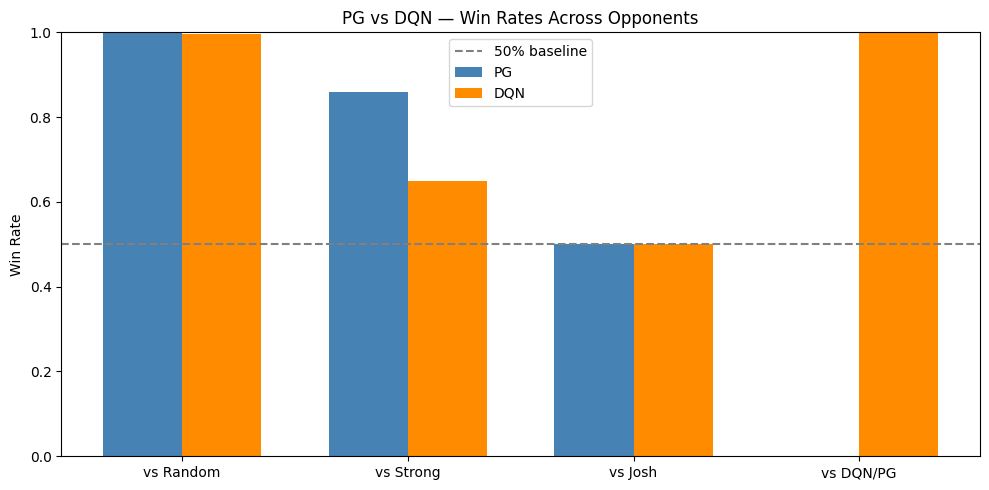

In [ ]:
# ── Comparison Bar Chart ─────────────────────────────────────────────────────
opponents = ["vs Random", "vs Strong", "vs Josh", "vs DQN/PG"]
pg_wins  = [
    results["PG vs Random"]["win_rate"],
    results["PG vs Strong"]["win_rate"],
    results["PG vs Josh"]["win_rate"],
    results["PG vs DQN"]["win_rate"],
]
dqn_wins = [
    results["DQN vs Random"]["win_rate"],
    results["DQN vs Strong"]["win_rate"],
    results["DQN vs Josh"]["win_rate"],
    results["DQN vs PG"]["win_rate"],
]

x   = np.arange(len(opponents))
w   = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, pg_wins,  w, label="PG",  color="steelblue")
ax.bar(x + w/2, dqn_wins, w, label="DQN", color="darkorange")
ax.axhline(0.5, color="gray", linestyle="--", label="50% baseline")
ax.set_xticks(x); ax.set_xticklabels(opponents)
ax.set_ylabel("Win Rate"); ax.set_ylim(0, 1)
ax.set_title("PG vs DQN — Win Rates Across Opponents")
ax.legend()
plt.tight_layout()
plt.savefig("pg_vs_dqn_comparison.png", dpi=150)
plt.show()

## Minimax Enhancement

We augment our trained models with a shallow Minimax search (depth = 2).

Key idea:
- The neural network evaluates board positions
- Minimax simulates future moves to improve decision quality

We use alpha-beta pruning to reduce computation.

Special handling:
- For Policy Gradient (PG), outputs are probabilities → converted to log-space
  for meaningful comparison during search.

In [ ]:
def minimax(board, depth, player, mm_player, model, alpha=-np.inf, beta=np.inf, is_pg=False):

    # Terminal state: assign win/loss/draw values
    done, winner = game_over(board)
    if done:
        if winner == mm_player:  return 1.0
        if winner != 0:          return -1.0
        return 0.0

    # Leaf node: evaluate board using neural network
    if depth == 0:
        enc   = encode_board(board, player)[np.newaxis].astype(np.float32)
        out = model(enc, training=False).numpy()[0]

        legal = legal_moves(board)

        # Mask illegal moves so they are never selected
        mask  = np.full(7, -1e9); mask[legal] = 0.0

        # PG outputs probabilities → convert to log-space for minimax
        if is_pg:
            out = np.log(out + 1e-8)

        return float(np.max(out + mask))

    cols = legal_moves(board)

    # Maximizing player (our agent)
    if player == mm_player:
        best = -np.inf
        for col in cols:
            new_board, _ = step(board, col, player)
            best  = max(best, minimax(new_board, depth-1, -player,
                                      mm_player, model, alpha, beta, is_pg))
            alpha = max(alpha, best)
            if beta <= alpha: break
        return best

    # Minimizing player (opponent)
    else:
        best = np.inf
        for col in cols:
            new_board, _ = step(board, col, player)
            best = min(best, minimax(new_board, depth-1, -player,
                                     mm_player, model, alpha, beta, is_pg))
            beta = min(beta, best)
            if beta <= alpha: break
        return best

### Minimax Move Selection

Before running search, we apply simple tactical rules:
1. Take a winning move if available
2. Block opponent’s winning move

If neither applies, Minimax is used to evaluate possible moves.

In [ ]:
def select_move_minimax(board, player, model, depth=2, is_pg=False):
    # Apply simple tactics before running minimax (win or block)
    col = find_winning_move(board, player)
    if col is not None: return col
    col = find_winning_move(board, -player)
    if col is not None: return col

    cols = legal_moves(board)
    best_score, best_col = -np.inf, cols[0]
    for col in cols:
        new_board, _ = step(board, col, player)
        score = minimax(new_board, depth-1, -player, player, model, is_pg=is_pg)
        if score > best_score:
            best_score, best_col = score, col
    return best_col


class MinimaxAgent:
    def __init__(self, model, depth=2, is_pg=False):
        self.model = model
        self.depth = depth
        self.is_pg = is_pg # whether model outputs probabilities (PG)

    def select_move(self, board, player):
        return select_move_minimax(board, player, self.model,
                                   self.depth, self.is_pg)


# create agents
mm_pg_agent  = MinimaxAgent(pg_model,  depth=2, is_pg=True)   # pg flag on
mm_dqn_agent = MinimaxAgent(dqn_model, depth=2, is_pg=False)  # dqn unchanged
print("Minimax agents ready")

Minimax agents ready


## Minimax Evaluation

We compare Minimax-enhanced agents against:
- Random agent
- Strong heuristic agent
- Josh's CNN
- Each other

We also compare against the original (non-Minimax) versions to measure improvement.

In [ ]:
# ── Fix Keras input warning before minimax runs ────────────────────────────
dummy_board = make_board()
dummy_enc   = encode_board(dummy_board, 1)[np.newaxis].astype(np.float32)

# warm up both models so Keras stops complaining
_ = pg_model(dummy_enc,  training=False)
_ = dqn_model(dummy_enc, training=False)
print("Models warmed up -- input structure cached.")

Models warmed up -- input structure cached.


In [ ]:
# ── Evaluate Minimax ─────────────────────────────────────────────────────────
N = 100

mm_matchups = [
    ("MM-PG vs Random",  mm_pg_agent,  random_agent),
    ("MM-DQN vs Random", mm_dqn_agent, random_agent),
    ("MM-PG vs Strong",  mm_pg_agent,  strong_agent),
    ("MM-DQN vs Strong", mm_dqn_agent, strong_agent),
    ("MM-PG vs Josh",    mm_pg_agent,  josh_agent),
    ("MM-DQN vs Josh",   mm_dqn_agent, josh_agent),
    ("MM-DQN vs MM-PG",  mm_dqn_agent, mm_pg_agent),
]

mm_results = {}
print(f"{'Matchup':<25} {'Win%':>6} {'Draw%':>7} {'Loss%':>7}")
print("-" * 50)

# Evaluate each matchup over N games and record win/draw/loss rates
for name, agent1, agent2 in mm_matchups:
    r    = evaluate_agents(agent1, agent2, n_games=N)
    win  = r['win_rate']
    draw = r.get('draw_rate', 1 - r['win_rate'] - r.get('loss_rate', 0))
    loss = 1 - win - draw
    mm_results[name] = r
    print(f"{name:<25} {win:>6.1%} {draw:>7.1%} {loss:>7.1%}")

Matchup                     Win%   Draw%   Loss%
--------------------------------------------------
MM-PG vs Random            97.0%    3.0%    0.0%
MM-DQN vs Random          100.0%    0.0%    0.0%
MM-PG vs Strong            37.0%   63.0%    0.0%
MM-DQN vs Strong           80.0%   20.0%    0.0%
MM-PG vs Josh               0.0%  100.0%    0.0%
MM-DQN vs Josh              0.0%  100.0%    0.0%
MM-DQN vs MM-PG            50.0%   50.0%    0.0%


## Strategy Comparison

We compare:
- Original models (PG, DQN)
- Minimax-enhanced versions (MM+PG, MM+DQN)

This shows whether search improves performance consistently across opponents.

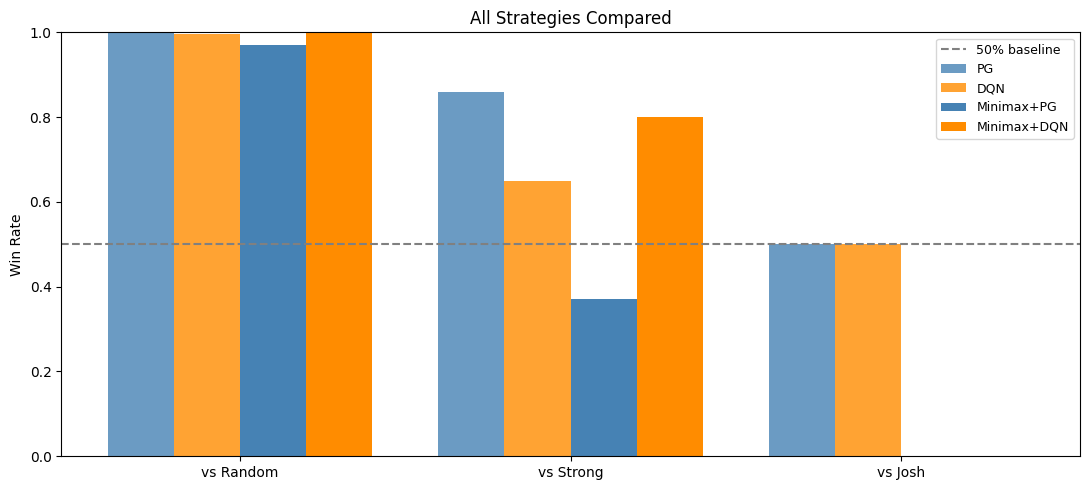

In [ ]:
# ── Full Summary Chart ───────────────────────────────────────────────────────
categories = ["vs Random", "vs Strong", "vs Josh"]
plain_pg  = [results["PG vs Random"]["win_rate"],
             results["PG vs Strong"]["win_rate"],
             results["PG vs Josh"]["win_rate"]]
plain_dqn = [results["DQN vs Random"]["win_rate"],
             results["DQN vs Strong"]["win_rate"],
             results["DQN vs Josh"]["win_rate"]]
mm_pg     = [mm_results["MM-PG vs Random"]["win_rate"],
             mm_results["MM-PG vs Strong"]["win_rate"],
             mm_results["MM-PG vs Josh"]["win_rate"]]
mm_dqn    = [mm_results["MM-DQN vs Random"]["win_rate"],
             mm_results["MM-DQN vs Strong"]["win_rate"],
             mm_results["MM-DQN vs Josh"]["win_rate"]]

x = np.arange(len(categories))
w = 0.2
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 1.5*w, plain_pg,  w, label="PG",          color="steelblue",   alpha=0.8)
ax.bar(x - 0.5*w, plain_dqn, w, label="DQN",         color="darkorange",  alpha=0.8)
ax.bar(x + 0.5*w, mm_pg,     w, label="Minimax+PG",  color="steelblue",   alpha=1.0)
ax.bar(x + 1.5*w, mm_dqn,    w, label="Minimax+DQN", color="darkorange",  alpha=1.0)
ax.axhline(0.5, color="gray", linestyle="--", label="50% baseline")
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylabel("Win Rate"); ax.set_ylim(0, 1)
ax.set_title("All Strategies Compared")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("full_comparison.png", dpi=150)
plt.show()

## Final Tournament Selection Metric

To fairly select the strongest reinforcement learning agent, we combine two evaluation perspectives:

### 1. Baseline Performance
Each agent is tested against fixed benchmark opponents:
- Random agent (lower bound)
- Strong rule-based agent (classical heuristic baseline)
- Pretrained CNN agent (Josh)

This measures **absolute performance strength**.

### 2. Peer Performance
Each agent is also tested against other learned RL agents:
- PG (Policy Gradient)
- DQN (Deep Q-Network)
- Minimax-enhanced DQN (MM-DQN)

This measures **competitive strength against similar policies**.

### 3. Combined Score
We compute a weighted final score:

- 60% baseline performance (robustness vs known benchmarks)
  - Random agent: 10% weight (lower bound sanity check)
  - StrongRuleAgent: 60% weight (primary benchmark)
  - Josh CNN: 30% weight (MCTS-level opponent)
- 40% peer performance (competitive strength against similar policies)

This ensures the selected model is both:
- Strong against standard baselines
- Competitive against other RL approaches

The agent with the highest final score is selected as the tournament model.

In [ ]:
# ── Final Tournament Selection ─────────────────────────────────────────────
baseline_opponents = [random_agent, strong_agent, josh_agent]

peer_opponents = {
    "PG":     pg_agent,
    "DQN":    dqn_agent,
    "MM-DQN": mm_dqn_agent,
}

baseline_scores = {}
for name, agent in peer_opponents.items():
    r_random = evaluate_agents(agent, random_agent, n_games=100)['win_rate']
    r_strong = evaluate_agents(agent, strong_agent, n_games=100)['win_rate']
    r_josh   = evaluate_agents(agent, josh_agent,   n_games=100)['win_rate']
    # weight: random 10%, strong 60%, josh 30%
    baseline_scores[name] = 0.1*r_random + 0.6*r_strong + 0.3*r_josh
    print(f"{name} baseline -- Random:{r_random:.0%} Strong:{r_strong:.0%} Josh:{r_josh:.0%} Weighted:{baseline_scores[name]:.3f}")

print()

peer_scores = {}
for name, agent in peer_opponents.items():
    wins = []
    for opp_name, opp_agent in peer_opponents.items():
        if opp_name == name:
            continue
        r = evaluate_agents(agent, opp_agent, n_games=50)
        wins.append(r["win_rate"])
        print(f"  {name} vs {opp_name}: {r['win_rate']:.0%}")
    peer_scores[name] = sum(wins) / len(wins)
    print(f"{name} peer score: {peer_scores[name]:.3f}\n")

final_scores = {}
for name in peer_opponents:
    final_scores[name] = 0.6 * baseline_scores[name] + 0.4 * peer_scores[name]

print(f"\n{'Agent':<12} {'Baseline':>10} {'Peer':>8} {'Final':>8}")
print("-" * 42)
for name in peer_opponents:
    print(f"{name:<12} {baseline_scores[name]:>10.3f} {peer_scores[name]:>8.3f} {final_scores[name]:>8.3f}")

winner = max(final_scores, key=final_scores.get)
print(f"\nSelected tournament agent: {winner}")
print(f"Final score: {final_scores[winner]:.3f}")
print("For tournament play: epsilon=0, strong=True, argmax move selection.")

PG baseline -- Random:100% Strong:89% Josh:50% Weighted:0.784
DQN baseline -- Random:99% Strong:65% Josh:50% Weighted:0.639
MM-DQN baseline -- Random:100% Strong:82% Josh:0% Weighted:0.592

  PG vs DQN: 0%
  PG vs MM-DQN: 100%
PG peer score: 0.500

  DQN vs PG: 100%
  DQN vs MM-DQN: 50%
DQN peer score: 0.750

  MM-DQN vs PG: 0%
  MM-DQN vs DQN: 50%
MM-DQN peer score: 0.250


Agent          Baseline     Peer    Final
------------------------------------------
PG                0.784    0.500    0.670
DQN               0.639    0.750    0.683
MM-DQN            0.592    0.250    0.455

Selected tournament agent: DQN
Final score: 0.683
For tournament play: epsilon=0, strong=True, argmax move selection.


## Qualitative Game Visualization

To complement the quantitative results, we visualize a few sample games between top agents (DQN, PG, and Minimax-enhanced DQN).

We run matches with both agents going first to account for first-move advantage. This allows us to verify that observed performance differences are reflected in actual gameplay.

In [ ]:
def pretty_board(board):
    symbols = {0: ".", 1: "X", -1: "O"}
    for row in board:
        print(" ".join(symbols[x] for x in row))
    print("0 1 2 3 4 5 6\n")

def play_game(agent1, agent2, name1="Agent1", name2="Agent2", delay=0.5):
    import time

    board = make_board()
    player = 1  # agent1 starts
    done = False

    print(f"{name1} (1) vs {name2} (-1)\n")
    pretty_board(board)
    print("\n" + "-"*30)

    while not done:
        if player == 1:
            move = agent1.select_move(board, player)
            name = name1
        else:
            move = agent2.select_move(board, player)
            name = name2

        board, _ = step(board, move, player)

        print(f"\n{name} plays column {move}")
        pretty_board(board)
        print("-"*30)

        done, winner = game_over(board)
        player *= -1

        time.sleep(delay)  # slow it down so you can watch

    # final result
    if winner == 1:
        print(f"\n{name1} wins!")
    elif winner == -1:
        print(f"\n{name2} wins!")
    else:
        print("\nDraw!")

In [ ]:
play_game(dqn_agent, mm_dqn_agent, "DQN", "MM-DQN")

DQN (1) vs MM-DQN (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X O . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . X . .
. . . X O . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O X . .
. . . X O 

In [ ]:
play_game(mm_dqn_agent, dqn_agent, "MM-DQN", "DQN")

MM-DQN (1) vs DQN (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 2
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . O X . 

In [ ]:
play_game(dqn_agent, pg_agent, "DQN", "PG")

DQN (1) vs PG (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 2
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . O X . . .
. . O X . . 

In [ ]:
play_game(pg_agent, dqn_agent, "PG", "DQN")

PG (1) vs DQN (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . X X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

DQN plays column 3
. . . . . . .
. . . . . . .
. . . O . . .
. . . O . . .
. . X X . . .
. . O X . . 

In [ ]:
play_game(pg_agent, mm_dqn_agent, "PG", "MM-DQN")

PG (1) vs MM-DQN (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X O . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

PG plays column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . X . .
. . . X O . .
. . . X O . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O X . .
. . . X O . .


In [ ]:
play_game(mm_dqn_agent, pg_agent, "MM-DQN", "PG")

MM-DQN (1) vs PG (-1)

. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6


------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 2
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

MM-DQN plays column 3
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . . X . . .
. . O X . . .
0 1 2 3 4 5 6

------------------------------

PG plays column 2
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . O X . . .


### Results Summary

- **DQN** beats **MM-DQN** when it goes first, and vice versa when **MM-DQN** goes first.
- **DQN** beats **PG** whether it goes first or second.
- **PG** beats **MM-DQN** whether it goes first or second.

These results align with earlier evaluations, confirming that **DQN** performs consistently well and wins the final metric. For tournament play, **DQN** will be used, specifically the model file `dqn_best_cont.keras`, which showed the best performance in our final evaluation.